In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Cargar el archivo CSV desde la carpeta data/raw/
df = pd.read_csv("../data/raw/Dry_Bean.csv")

# 2. Eliminar filas duplicadas
df_clean = df.drop_duplicates().reset_index(drop=True)

# 3. Limpiar espacios en la columna Class
df_clean["Class"] = df_clean["Class"].astype(str).str.strip()

# 4. Confirmar cuantas filas quedaron
print(f"Filas listas para el EDA: {df_clean.shape[0]}")
print("\nDistribución de las clases limpias:")
print(df_clean["Class"].value_counts())

# Mostrar las primeras filas
df_clean.head()

ModuleNotFoundError: No module named 'matplotlib'

/tmp/ipykernel_1603/2547154992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


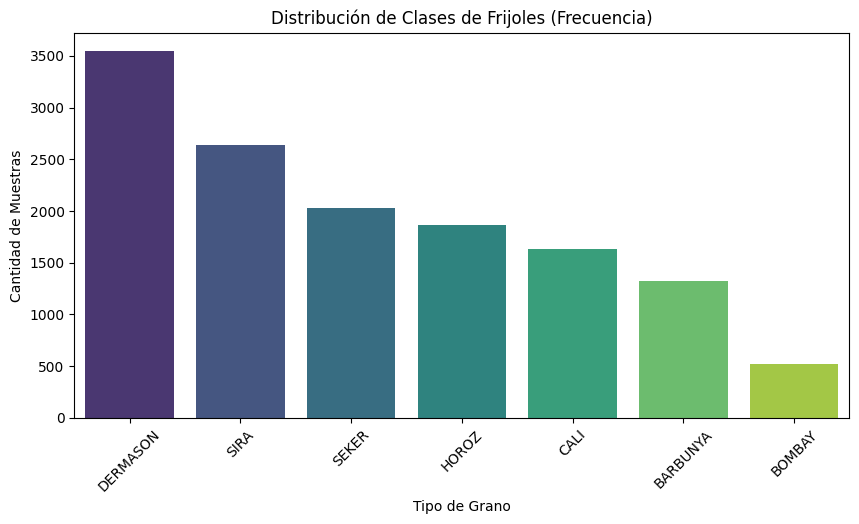

In [ ]:
# Gráfico de barras para ver la distribución de cada clase de grano
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_clean,
    x="Class",
    order=df_clean["Class"].value_counts().index,
    palette="viridis",
)
plt.title("Distribución de Clases de Frijoles (Frecuencia)")
plt.xlabel("Tipo de Grano")
plt.ylabel("Cantidad de Muestras")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1603/1228121029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


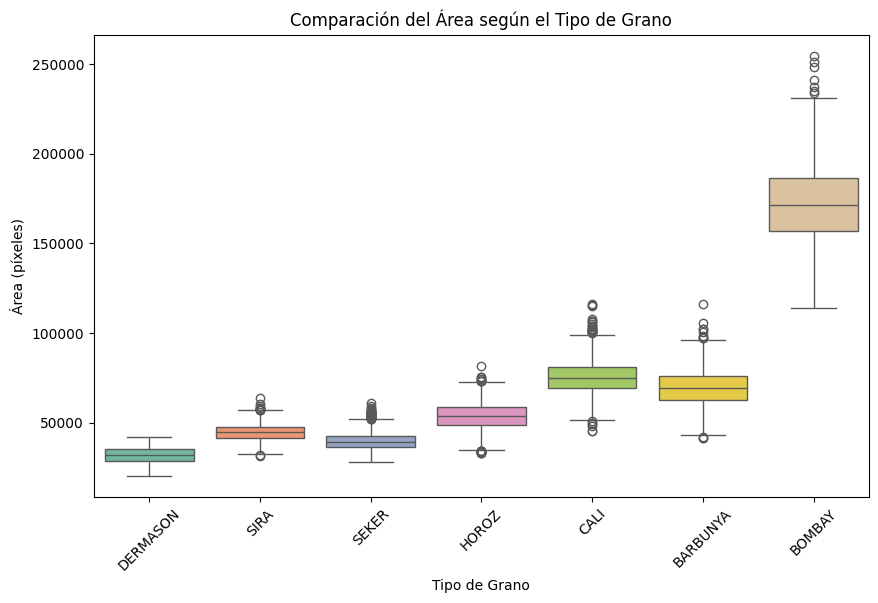

In [ ]:
# Boxplot de Área por Clase
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x="Class",
    y="Area",
    order=df_clean["Class"].value_counts().index,
    palette="Set2",
)
plt.title("Comparación del Área según el Tipo de Grano")
plt.xlabel("Tipo de Grano")
plt.ylabel("Área (píxeles)")
plt.xticks(rotation=45)
plt.show()

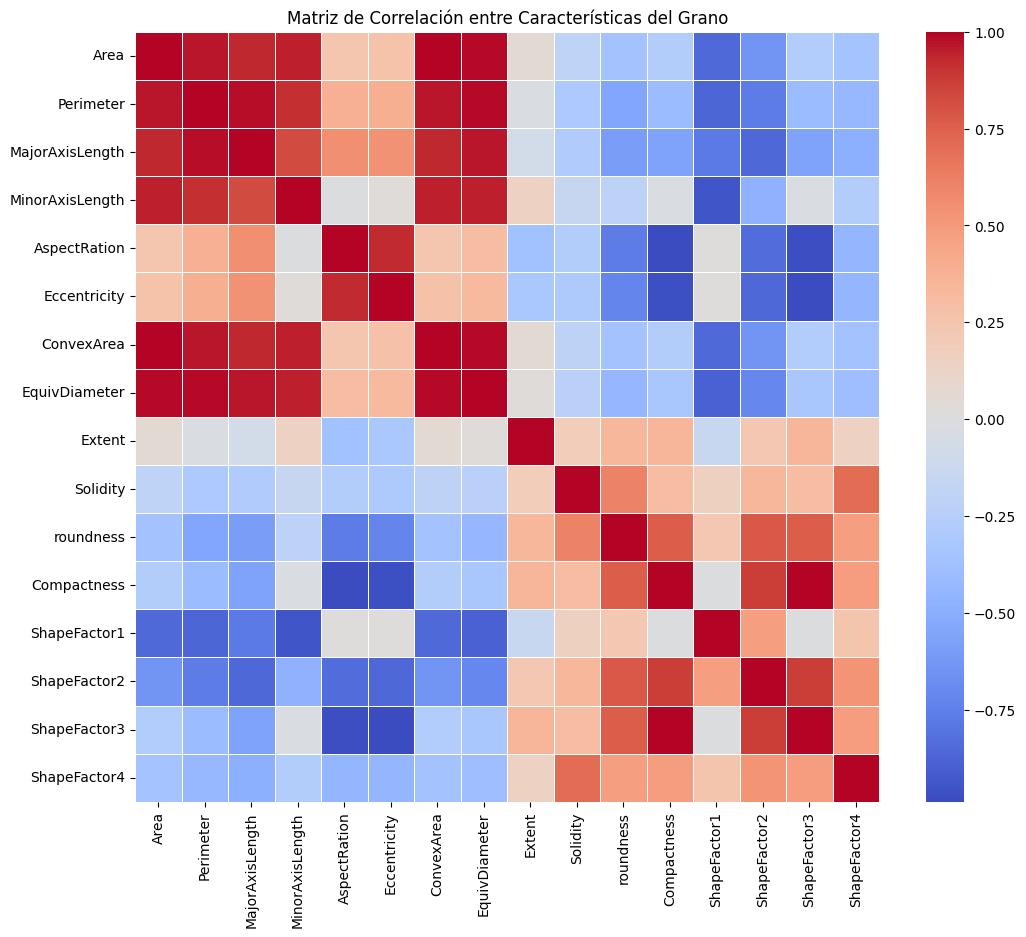

In [ ]:
# Matriz de Correlación entre las características numéricas
plt.figure(figsize=(12, 10))

# Calculamos la matriz excluyendo la columna categórica 'Class'
matriz_corr = df_clean.drop("Class", axis=1).corr()

# Dibujamos el mapa de calor
sns.heatmap(matriz_corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación entre Características del Grano")
plt.show()

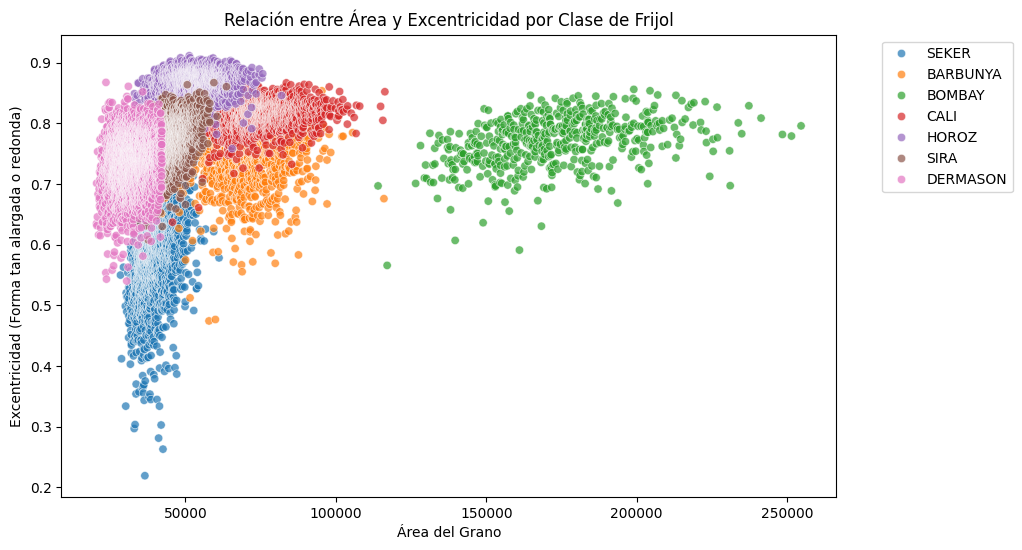

In [ ]:
# Gráfico de dispersión para ver cómo interactúan el Área y la Excentricidad
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="Area",
    y="Eccentricity",
    hue="Class",
    alpha=0.7,
    palette="tab10",
)
plt.title("Relación entre Área y Excentricidad por Clase de Frijol")
plt.xlabel("Área del Grano")
plt.ylabel("Excentricidad (Forma tan alargada o redonda)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()